In [1]:
import pandas as pd
import numpy as np

from scipy.optimize import minimize

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# =========================
# 1. 读取清洗后的底表
# 这里必须有历史收益数据，MVO 要用它算协方差矩阵
# =========================
df_model = pd.read_csv("cleaned_model_data.csv")
df_model["MthCalDt"] = pd.to_datetime(df_model["MthCalDt"])

# =========================
# 2. 读取 post-2022 的 RF 选股结果
# 这是你前面已经保存好的文件
# =========================
rf_stock_selection_df = pd.read_csv("rf_top6_stock_selection_post2022.csv")
rf_stock_selection_df["MthCalDt"] = pd.to_datetime(rf_stock_selection_df["MthCalDt"])

rf_monthly_results_df = pd.read_csv("rf_monthly_results_post2022.csv")

print("df_model shape:", df_model.shape)
print("rf_stock_selection_df shape:", rf_stock_selection_df.shape)
print("rf_monthly_results_df shape:", rf_monthly_results_df.shape)

display(rf_stock_selection_df.head(10))

df_model shape: (1590627, 22)
rf_stock_selection_df shape: (72, 8)
rf_monthly_results_df shape: (12, 6)


,rebalance_month,holding_month,PERMNO,MthCalDt,rf_pred,y_next,DollarVol,rank_in_portfolio
0,202412,202501,93436,2024-12-31,0.033954,-0.001818,7.651331e+11,1
1,202412,202501,11308,2024-12-31,0.033954,0.015895,2.435211e+10,2
2,202412,202501,18163,2024-12-31,0.033954,-0.007530,2.244687e+10,3
3,202412,202501,14702,2024-12-31,0.033954,0.105259,2.261056e+10,4
4,202412,202501,38703,2024-12-31,0.033954,0.118168,2.268532e+10,5
5,202412,202501,20357,2024-12-31,0.033954,-0.058285,2.330249e+10,6
6,202501,202502,86580,2025-01-31,0.018532,0.037093,7.097812e+11,1
7,202501,202502,18726,2025-01-31,0.018532,-0.024427,2.595369e+10,2
8,202501,202502,11762,2025-01-31,0.018532,-0.104758,2.383691e+10,3
9,202501,202502,14541,2025-01-31,0.018532,0.071612,2.400105e+10,4


In [2]:
# =========================
# 3. 准备全量月份序列
# 用 cleaned_model_data.csv 的完整历史来找过去36个月
# 这样虽然研究 post-2022，但协方差仍然可以严格取 rebalance month 前36个月
# =========================
all_months_full = sorted(df_model["DateKey"].unique())

# 只保留 post-2022 里真正出现过的 rebalance months
rebalance_months = sorted(rf_stock_selection_df["rebalance_month"].unique())

print("Number of rebalance months:", len(rebalance_months))
print("First 5 rebalance months:", rebalance_months[:5])
print("Last 5 rebalance months :", rebalance_months[-5:])

# =========================
# 4. 定义一个函数：给定月份，找它之前（含当月）的36个月窗口
# =========================
def get_rolling_window_months(current_month, all_months, window_size=36):
    idx = all_months.index(current_month)
    if idx < window_size - 1:
        return None
    return all_months[idx - window_size + 1 : idx + 1]

# =========================
# 5. 定义 Sharpe ratio 最大化问题
# maximize w' mu / sqrt(w' Sigma w)
# scipy 是做最小化，所以返回负的 Sharpe
# =========================
def negative_sharpe_ratio(weights, mu, cov):
    portfolio_return = np.dot(weights, mu)
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))

    if portfolio_vol == 0:
        return 1e6

    return -(portfolio_return / portfolio_vol)

# =========================
# 6. 定义 MVO 求解函数
# long-only, fully invested, optional upper bound
# =========================
def solve_mvo(mu, cov, upper_bound=0.4):
    n = len(mu)

    # 初始权重：等权
    init_w = np.repeat(1 / n, n)

    # 约束：权重和为1
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    ]

    # 边界：0 <= w <= upper_bound
    bounds = [(0, upper_bound) for _ in range(n)]

    result = minimize(
        fun=negative_sharpe_ratio,
        x0=init_w,
        args=(mu, cov),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x
    else:
        # 如果优化失败，退回等权
        return init_w

Number of rebalance months: 12
First 5 rebalance months: [np.int64(202412), np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504)]
Last 5 rebalance months : [np.int64(202507), np.int64(202508), np.int64(202509), np.int64(202510), np.int64(202511)]


In [4]:
# =========================
# 7. 主循环：对每个 rebalance month 做 MVO
# 基于 RF 已选出的 top 6 股票
# =========================
mvo_monthly_results = []
mvo_stock_weights = []

for month in rebalance_months:
    # -------------------------
    # A. 取该月 RF 选出的 6 只股票
    # -------------------------
    selected = rf_stock_selection_df[
        rf_stock_selection_df["rebalance_month"] == month
    ].sort_values("rank_in_portfolio").copy()

    # 必须正好有 6 只
    if len(selected) != 6:
        continue

    stock_ids = selected["PERMNO"].tolist()
    mu = selected["rf_pred"].values              # expected return vector
    realized_next = selected["y_next"].values    # 下一月真实超额收益

    # -------------------------
    # B. 找该月之前（含当月）的过去 36 个月窗口
    # -------------------------
    window_months = get_rolling_window_months(
        current_month=month,
        all_months=all_months_full,
        window_size=36
    )

    if window_months is None:
        continue

    # -------------------------
    # C. 提取这 6 只股票过去 36 个月历史收益
    # 这里用 ExcessRet 来估计协方差矩阵
    # -------------------------
    hist_data = df_model[
        (df_model["DateKey"].isin(window_months)) &
        (df_model["PERMNO"].isin(stock_ids))
    ][["DateKey", "PERMNO", "ExcessRet"]].copy()

    if hist_data.empty:
        continue

    # -------------------------
    # D. 处理重复值：
    # 如果同一 DateKey + PERMNO 有多条记录，先聚合成唯一值
    # 这里取均值
    # -------------------------
    hist_data = (
        hist_data.groupby(["DateKey", "PERMNO"], as_index=False)["ExcessRet"]
        .mean()
    )

    # -------------------------
    # E. 转成宽表：行=月份，列=股票，值=ExcessRet
    # -------------------------
    hist_pivot = hist_data.pivot(
        index="DateKey",
        columns="PERMNO",
        values="ExcessRet"
    )

    # 保证列顺序和 stock_ids 一致
    hist_pivot = hist_pivot.reindex(columns=stock_ids)

    # -------------------------
    # F. 删除含缺失的月份
    # 只保留 6 只股票都有收益的月份
    # -------------------------
    hist_pivot = hist_pivot.dropna()

    # 至少保留一定数量历史月份，否则协方差不稳定
    if hist_pivot.shape[0] < 12:
        continue

    # -------------------------
    # G. 计算协方差矩阵
    # 为了数值稳定，在对角线上加一个很小的 ridge
    # -------------------------
    cov = hist_pivot.cov().values
    cov = cov + np.eye(len(stock_ids)) * 1e-6

    # -------------------------
    # H. 求解 MVO 最优权重
    # -------------------------
    weights = solve_mvo(mu=mu, cov=cov, upper_bound=0.4)

    # -------------------------
    # I. 计算下一月组合收益
    # MVO 收益 = 权重 × 下一月真实收益
    # 同时保留等权收益做检查
    # -------------------------
    mvo_return = np.dot(weights, realized_next)
    ew_return = np.mean(realized_next)

    # -------------------------
    # J. 保存月度组合结果
    # -------------------------
    mvo_monthly_results.append({
        "rebalance_month": month,
        "holding_month": selected["holding_month"].iloc[0],
        "n_selected": len(stock_ids),
        "n_hist_months_used": hist_pivot.shape[0],
        "rf_mvo_return": mvo_return,
        "rf_ew_return_check": ew_return
    })

    # -------------------------
    # K. 保存每只股票的权重结果
    # -------------------------
    stock_weight_output = selected[
        ["rebalance_month", "holding_month", "PERMNO", "rf_pred", "y_next", "rank_in_portfolio"]
    ].copy()

    stock_weight_output["mvo_weight"] = weights
    stock_weight_output["hist_months_used"] = hist_pivot.shape[0]

    mvo_stock_weights.append(stock_weight_output)

print("MVO loop completed.")

MVO loop completed.


In [5]:
# =========================
# 8. 拼接结果表
# =========================
mvo_monthly_results_df = pd.DataFrame(mvo_monthly_results)

mvo_stock_weights_df = (
    pd.concat(mvo_stock_weights, ignore_index=True)
    if mvo_stock_weights else pd.DataFrame()
)

print("mvo_monthly_results_df shape:", mvo_monthly_results_df.shape)
print("mvo_stock_weights_df shape :", mvo_stock_weights_df.shape)

display(mvo_monthly_results_df.head())
display(mvo_stock_weights_df.head(12))

# =========================
# 9. 保存结果
# =========================
mvo_monthly_results_df.to_csv("rf_mvo_monthly_results_post2022.csv", index=False)
mvo_stock_weights_df.to_csv("rf_mvo_stock_weights_post2022.csv", index=False)

print("Saved files:")
print("- rf_mvo_monthly_results_post2022.csv")
print("- rf_mvo_stock_weights_post2022.csv")

mvo_monthly_results_df shape: (11, 6)
mvo_stock_weights_df shape : (66, 8)


,rebalance_month,holding_month,n_selected,n_hist_months_used,rf_mvo_return,rf_ew_return_check
0,202501,202502,6,33,-0.004525,-0.014975
1,202502,202503,6,36,-0.062570,-0.066379
2,202503,202504,6,36,0.023768,0.000161
3,202504,202505,6,36,0.004095,0.016789
4,202505,202506,6,12,0.023654,0.070591


,rebalance_month,holding_month,PERMNO,rf_pred,y_next,rank_in_portfolio,mvo_weight,hist_months_used
0,202501,202502,86580,0.018532,0.037093,1,0.000000e+00,33
1,202501,202502,18726,0.018532,-0.024427,2,1.779420e-01,33
2,202501,202502,11762,0.018532,-0.104758,3,3.260086e-01,33
3,202501,202502,14541,0.018532,0.071612,4,4.000000e-01,33
4,202501,202502,14702,0.018532,-0.124846,5,3.222348e-17,33
5,202501,202502,86783,0.018532,0.055475,6,9.604941e-02,33
6,202502,202503,86580,-0.029943,-0.135730,1,4.000000e-01,36
7,202502,202503,78975,-0.029943,-0.003156,2,2.000000e-01,36
8,202502,202503,57665,-0.029943,-0.200129,3,0.000000e+00,36
9,202502,202503,86456,-0.029943,-0.039085,4,0.000000e+00,36


Saved files:
- rf_mvo_monthly_results_post2022.csv
- rf_mvo_stock_weights_post2022.csv


In [6]:
# =========================
# 10. 计算 MVO 组合表现
# =========================
portfolio_returns_mvo = mvo_monthly_results_df["rf_mvo_return"].dropna()

annualized_return_mvo = (1 + portfolio_returns_mvo).prod() ** (12 / len(portfolio_returns_mvo)) - 1
annualized_vol_mvo = portfolio_returns_mvo.std() * np.sqrt(12)

if portfolio_returns_mvo.std() != 0:
    sharpe_ratio_mvo = (portfolio_returns_mvo.mean() / portfolio_returns_mvo.std()) * np.sqrt(12)
else:
    sharpe_ratio_mvo = np.nan

wealth_mvo = (1 + portfolio_returns_mvo).cumprod()
peak_mvo = wealth_mvo.cummax()
drawdown_mvo = (peak_mvo - wealth_mvo) / peak_mvo
max_drawdown_mvo = drawdown_mvo.max()

print("Random Forest + MVO Portfolio Performance (Post-2022 only)")
print("Annualized Return    :", round(annualized_return_mvo, 6))
print("Annualized Volatility:", round(annualized_vol_mvo, 6))
print("Sharpe Ratio         :", round(sharpe_ratio_mvo, 6))
print("Max Drawdown         :", round(max_drawdown_mvo, 6))

Random Forest + MVO Portfolio Performance (Post-2022 only)
Annualized Return    : 0.074478
Annualized Volatility: 0.113475
Sharpe Ratio         : 0.686859
Max Drawdown         : 0.06257


In [7]:
# =========================
# 11. 读取 RF 等权月度结果做对比
# rf_monthly_results_df 是前面已保存的 post-2022 等权结果
# =========================
rf_monthly_results_df = pd.read_csv("rf_monthly_results_post2022.csv")

portfolio_returns_ew = rf_monthly_results_df["rf_ew_return"].dropna()

annualized_return_ew = (1 + portfolio_returns_ew).prod() ** (12 / len(portfolio_returns_ew)) - 1
annualized_vol_ew = portfolio_returns_ew.std() * np.sqrt(12)

if portfolio_returns_ew.std() != 0:
    sharpe_ratio_ew = (portfolio_returns_ew.mean() / portfolio_returns_ew.std()) * np.sqrt(12)
else:
    sharpe_ratio_ew = np.nan

wealth_ew = (1 + portfolio_returns_ew).cumprod()
peak_ew = wealth_ew.cummax()
drawdown_ew = (peak_ew - wealth_ew) / peak_ew
max_drawdown_ew = drawdown_ew.max()

comparison_df = pd.DataFrame({
    "Portfolio": ["RF + Equal Weight", "RF + MVO"],
    "Annualized Return": [annualized_return_ew, annualized_return_mvo],
    "Annualized Volatility": [annualized_vol_ew, annualized_vol_mvo],
    "Sharpe Ratio": [sharpe_ratio_ew, sharpe_ratio_mvo],
    "Max Drawdown": [max_drawdown_ew, max_drawdown_mvo]
})

display(comparison_df.round(6))

comparison_df.to_csv("rf_portfolio_comparison_post2022.csv", index=False)
print("Saved: rf_portfolio_comparison_post2022.csv")

,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,RF + Equal Weight,0.210254,0.129452,1.545340,0.08036
1,RF + MVO,0.074478,0.113475,0.686859,0.06257


Saved: rf_portfolio_comparison_post2022.csv


,holding_month,rf_ew_return,rf_mvo_return,wealth_ew,wealth_mvo
0,2025-02-01,-0.014975,-0.004525,0.985025,0.995475
1,2025-03-01,-0.066379,-0.062570,0.919640,0.933188
2,2025-04-01,0.000160,0.023768,0.919788,0.955368
3,2025-05-01,0.016789,0.004095,0.935230,0.959280
4,2025-06-01,0.070591,0.023654,1.001249,0.981971


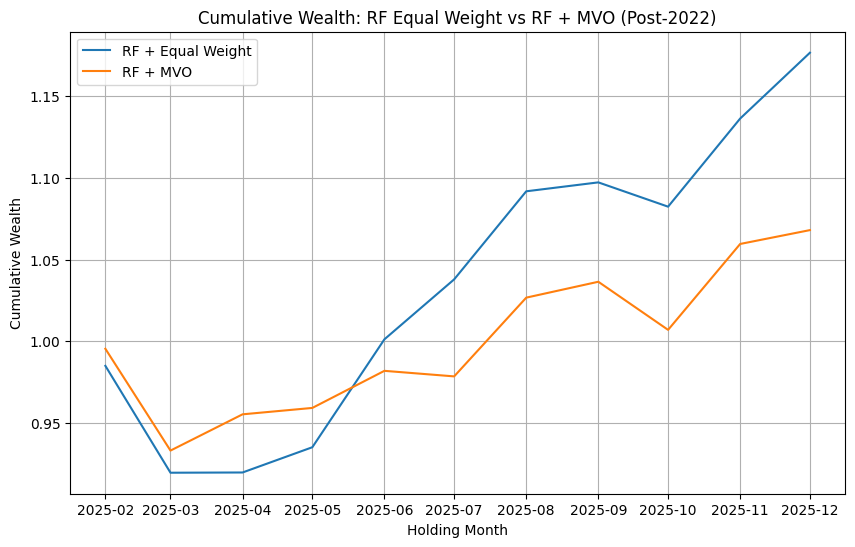

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取结果表
# =========================
rf_monthly_results_df = pd.read_csv("rf_monthly_results_post2022.csv")
mvo_monthly_results_df = pd.read_csv("rf_mvo_monthly_results_post2022.csv")

# =========================
# 2. 取两种组合的月度收益
# =========================
ew_returns = rf_monthly_results_df[["holding_month", "rf_ew_return"]].copy()
mvo_returns = mvo_monthly_results_df[["holding_month", "rf_mvo_return"]].copy()

# 合并到同一张表
compare_returns = pd.merge(
    ew_returns,
    mvo_returns,
    on="holding_month",
    how="inner"
).sort_values("holding_month").reset_index(drop=True)

# 把 holding_month 转成日期，方便画图
compare_returns["holding_month"] = pd.to_datetime(
    compare_returns["holding_month"].astype(str) + "01",
    format="%Y%m%d"
)

# =========================
# 3. 计算累计财富
# 初始财富设为 1
# =========================
compare_returns["wealth_ew"] = (1 + compare_returns["rf_ew_return"]).cumprod()
compare_returns["wealth_mvo"] = (1 + compare_returns["rf_mvo_return"]).cumprod()

display(compare_returns.head())

# =========================
# 4. 画累计财富曲线
# =========================
plt.figure(figsize=(10, 6))
plt.plot(compare_returns["holding_month"], compare_returns["wealth_ew"], label="RF + Equal Weight")
plt.plot(compare_returns["holding_month"], compare_returns["wealth_mvo"], label="RF + MVO")

plt.title("Cumulative Wealth: RF Equal Weight vs RF + MVO (Post-2022)")
plt.xlabel("Holding Month")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True)
plt.show()

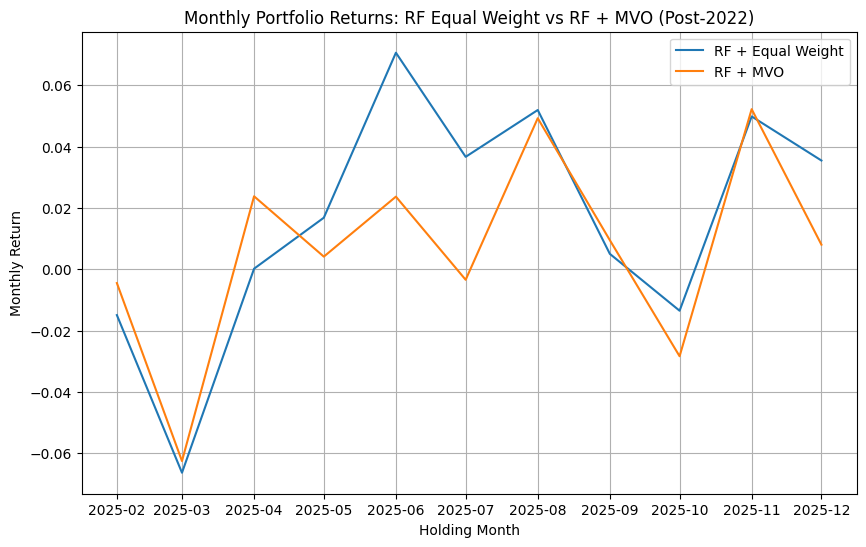

In [9]:
# =========================
# 5. 画月度收益对比图
# =========================
plt.figure(figsize=(10, 6))
plt.plot(compare_returns["holding_month"], compare_returns["rf_ew_return"], label="RF + Equal Weight")
plt.plot(compare_returns["holding_month"], compare_returns["rf_mvo_return"], label="RF + MVO")

plt.title("Monthly Portfolio Returns: RF Equal Weight vs RF + MVO (Post-2022)")
plt.xlabel("Holding Month")
plt.ylabel("Monthly Return")
plt.legend()
plt.grid(True)
plt.show()

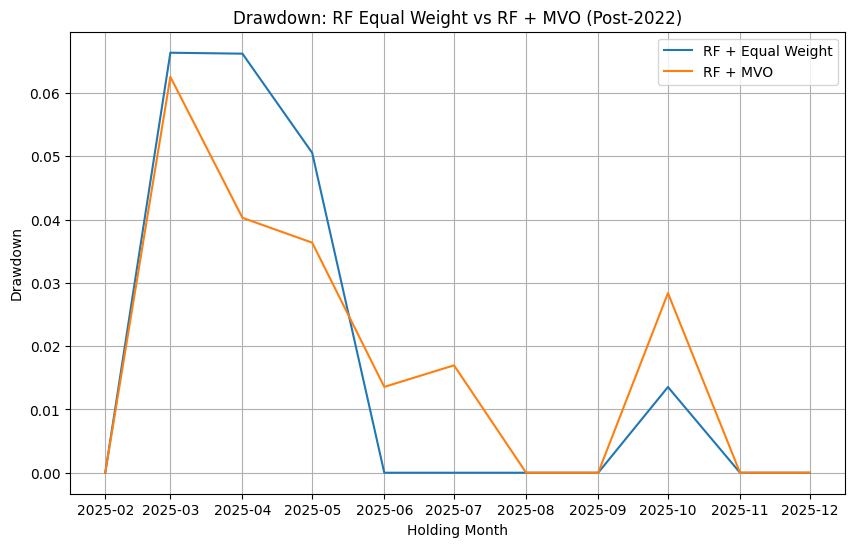

In [10]:
# =========================
# 6. 计算并画回撤曲线
# =========================
compare_returns["peak_ew"] = compare_returns["wealth_ew"].cummax()
compare_returns["drawdown_ew"] = (
    compare_returns["peak_ew"] - compare_returns["wealth_ew"]
) / compare_returns["peak_ew"]

compare_returns["peak_mvo"] = compare_returns["wealth_mvo"].cummax()
compare_returns["drawdown_mvo"] = (
    compare_returns["peak_mvo"] - compare_returns["wealth_mvo"]
) / compare_returns["peak_mvo"]

plt.figure(figsize=(10, 6))
plt.plot(compare_returns["holding_month"], compare_returns["drawdown_ew"], label="RF + Equal Weight")
plt.plot(compare_returns["holding_month"], compare_returns["drawdown_mvo"], label="RF + MVO")

plt.title("Drawdown: RF Equal Weight vs RF + MVO (Post-2022)")
plt.xlabel("Holding Month")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# =========================
# 12. 每个月 top6 股票 + MVO 权重，整理成宽表
# =========================
mvo_wide = mvo_stock_weights_df[
    ["rebalance_month", "holding_month", "rank_in_portfolio", "PERMNO", "rf_pred", "y_next", "mvo_weight"]
].sort_values(["rebalance_month", "rank_in_portfolio"]).copy()

permno_wide = mvo_wide.pivot(
    index=["rebalance_month", "holding_month"],
    columns="rank_in_portfolio",
    values="PERMNO"
)
permno_wide.columns = [f"stock_{i}" for i in permno_wide.columns]

pred_wide = mvo_wide.pivot(
    index=["rebalance_month", "holding_month"],
    columns="rank_in_portfolio",
    values="rf_pred"
)
pred_wide.columns = [f"pred_{i}" for i in pred_wide.columns]

actual_wide = mvo_wide.pivot(
    index=["rebalance_month", "holding_month"],
    columns="rank_in_portfolio",
    values="y_next"
)
actual_wide.columns = [f"actual_{i}" for i in actual_wide.columns]

weight_wide = mvo_wide.pivot(
    index=["rebalance_month", "holding_month"],
    columns="rank_in_portfolio",
    values="mvo_weight"
)
weight_wide.columns = [f"weight_{i}" for i in weight_wide.columns]

mvo_top6_by_month = pd.concat(
    [permno_wide, pred_wide, actual_wide, weight_wide],
    axis=1
).reset_index()

mvo_top6_by_month.to_csv("rf_mvo_top6_by_month_post2022.csv", index=False)

print("Saved: rf_mvo_top6_by_month_post2022.csv")
display(mvo_top6_by_month.head())

Saved: rf_mvo_top6_by_month_post2022.csv


,rebalance_month,holding_month,stock_1,stock_2,stock_3,stock_4,stock_5,stock_6,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,actual_1,actual_2,actual_3,actual_4,actual_5,actual_6,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6
0,202501,202502,86580,18726,11762,14541,14702,86783,0.018532,0.018532,0.018532,0.018532,0.018532,0.018532,0.037093,-0.024427,-0.104758,0.071612,-0.124846,0.055475,0.000000e+00,0.177942,3.260086e-01,4.000000e-01,3.222348e-17,9.604941e-02
1,202502,202503,86580,78975,57665,86456,75186,13721,-0.029943,-0.029943,-0.029943,-0.029943,-0.029943,-0.029943,-0.135730,-0.003156,-0.200129,-0.039085,-0.019117,-0.001056,4.000000e-01,0.200000,0.000000e+00,0.000000e+00,4.000000e-01,2.011880e-16
2,202503,202504,84398,66181,65875,66093,89071,86783,-0.024001,-0.024001,-0.024001,-0.024001,-0.024001,-0.024001,-0.012170,-0.019872,-0.016827,-0.013710,-0.039834,0.103376,2.220446e-16,0.316523,5.338024e-16,6.661338e-16,2.834775e-01,4.000000e-01
3,202504,202505,84398,92027,77178,57665,89469,14541,0.026612,0.026612,0.026612,0.026612,0.026612,0.026612,0.059045,-0.000174,-0.025759,0.070491,-0.016178,0.013309,1.743429e-01,0.400000,1.645923e-13,1.321499e-13,4.000000e-01,2.565714e-02
4,202505,202506,84398,77178,19383,18163,88360,21619,0.026386,0.026386,0.026386,0.026386,0.026386,0.026386,0.047994,0.100047,-0.000033,-0.065617,0.282528,0.058626,3.227155e-01,0.159200,4.000000e-01,1.180842e-01,0.000000e+00,0.000000e+00
